# Waterfall Build-up — Incremental Component Analysis (3 × 3 Full Suite)

This notebook visualises the Pareto front progression as the algorithmic pipeline grows from a minimal baseline to the full proposed method, across **all 9 (dataset × hardware) combinations**.

| Stage | Label | Components |
|---|---|---|
| 1 | Random Search | Random sampling only |
| 2 | MOEA/D + GA | Decomposition + genetic operators |
| 3 | MOEA/D + GA + PSO | + Discrete PSO velocity update |
| 4 | Full Proposed | + Simulated Annealing local search |

**Budget:** 2 000 NFE per stage · **Seeds:** seed=42 per combo  
**Structure:** 3 datasets (CIFAR-10 / CIFAR-100 / ImageNet-16) × 3 hardware (EdgeGPU / RPi-4 / Eyeriss)  
**Outputs:** 3×3 Pareto overlay grid · HV/IGD progression curves per combo · Metric summary table


In [1]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError("Unable to locate the repository root for HW-NAS-Memetic.")
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from src.analysis.data_loader import (
    DATASETS, HARDWARE,
    load_archive, load_incremental_archive,
)
from src.utils.pareto_math import to_display, normalise_to_bounds
from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_BASE = PROJECT_ROOT / "results" / "incremental"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures" / "waterfall"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size":  10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Stage catalogue ──────────────────────────────────────────────────────────
# (filename, display label, colour)
STAGES = [
    ("stage1_random.json",      "Random Search",    "#7f7f7f"),
    ("stage2_moead_ga.json",    "MOEA/D + GA",      "#ff7f0e"),
    ("stage3_moead_ga_pso.json","MOEA/D+GA+PSO",    "#2ca02c"),
    ("stage4_full.json",        "Full Proposed",    "#1f77b4"),
]

# ── Labels ───────────────────────────────────────────────────────────────────
DS_LABEL = {
    "cifar10":        "CIFAR-10",
    "cifar100":       "CIFAR-100",
    "ImageNet16-120": "ImageNet-16",
}
HW_LABEL = {
    "edgegpu_latency": "EdgeGPU",
    "raspi4_latency":  "RPi-4",
    "eyeriss_latency": "Eyeriss",
}

REF = np.array([1.1, 1.1])

print("Setup complete.")
print(f"Datasets : {DATASETS}")
print(f"Hardware : {HARDWARE}")
print(f"Stages   : {[s[1] for s in STAGES]}")


PROJECT_ROOT = /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic
Setup complete.
Datasets : ['cifar10', 'cifar100', 'ImageNet16-120']
Hardware : ['edgegpu_latency', 'raspi4_latency', 'eyeriss_latency']
Stages   : ['Random Search', 'MOEA/D + GA', 'MOEA/D+GA+PSO', 'Full Proposed']


In [2]:
# ── Cell 2: Load all 9 combos + compute stage metrics ────────────────────────
# stage_data[ds][hw] = list of {label, color, front, acc, lat, hv, igd}
stage_data   = {ds: {hw: [] for hw in HARDWARE} for ds in DATASETS}
metric_records = []

print("Loading incremental archives …\n")
for ds in DATASETS:
    for hw in HARDWARE:
        combo_stages = []
        all_fronts   = []

        for fname, label, color in STAGES:
            try:
                archive = load_incremental_archive(RESULTS_BASE, ds, hw, fname)
            except FileNotFoundError:
                combo_stages.append(None)
                continue
            pts   = archive_to_points(archive)
            front = get_pareto_front(pts)
            acc, lat = to_display(front)
            combo_stages.append({
                "label":   label,
                "color":   color,
                "front":   front,
                "acc":     acc,
                "lat":     lat,
            })
            all_fronts.append(front)

        if not all_fronts:
            print(f"  [{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]  SKIP (no data)")
            continue

        # Normalise using global proxy across all stages in this combo
        proxy     = get_pareto_front(np.vstack(all_fronts))
        pmin      = proxy.min(axis=0)
        prange    = np.where(proxy.max(axis=0) - pmin > 0, proxy.max(axis=0) - pmin, 1.0)
        proxy_n   = normalise_to_bounds(proxy, pmin, prange)

        print(f"  [{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]")
        for entry, (fname, label, color) in zip(combo_stages, STAGES):
            if entry is None:
                print(f"    {label:<22}  MISSING")
                metric_records.append({"Dataset": DS_LABEL[ds], "Hardware": HW_LABEL[hw],
                                        "Stage": label, "HV": float("nan"), "IGD": float("nan"),
                                        "Pareto Points": 0})
                continue
            nf  = normalise_to_bounds(entry["front"], pmin, prange)
            hv  = calc_hv(nf, ref_point=REF)
            igd = calc_igd(nf, proxy_n)
            entry["hv"]  = hv
            entry["igd"] = igd
            print(f"    {label:<22}  HV={hv:.4f}  IGD={igd:.4f}  pts={len(entry['acc'])}")
            metric_records.append({
                "Dataset":       DS_LABEL[ds],
                "Hardware":      HW_LABEL[hw],
                "ds_key":        ds,
                "hw_key":        hw,
                "Stage":         label,
                "stage_idx":     STAGES.index((fname, label, color)),
                "HV":            hv,
                "IGD":           igd,
                "Pareto Points": len(entry["acc"]),
            })

        stage_data[ds][hw] = [e for e in combo_stages if e is not None]

metrics_df = pd.DataFrame(metric_records)
print(f"\nTotal metric rows: {len(metrics_df)}")


Loading incremental archives …

  [CIFAR-10     x EdgeGPU ]

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

    Random Search           HV=1.0535  IGD=0.0074  pts=13
    MOEA/D + GA             HV=1.0543  IGD=0.0012  pts=155


    MOEA/D+GA+PSO           HV=1.0539  IGD=0.0070  pts=518
    Full Proposed           HV=1.0517  IGD=0.0029  pts=812
  [CIFAR-10     x RPi-4   ]
    Random Search           HV=1.1584  IGD=0.0081  pts=27
    MOEA/D + GA             HV=1.1588  IGD=0.0004  pts=82
    MOEA/D+GA+PSO           HV=1.1578  IGD=0.0042  pts=469
    Full Proposed           HV=1.1577  IGD=0.0019  pts=669
  [CIFAR-10     x Eyeriss ]
    Random Search           HV=1.0184  IGD=0.0766  pts=14
    MOEA/D + GA             HV=1.0219  IGD=0.0073  pts=63
    MOEA/D+GA+PSO           HV=1.0296  IGD=0.0012  pts=193
    Full Proposed           HV=1.0297  IGD=0.0058  pts=451
  [CIFAR-100    x EdgeGPU ]
    Random Search           HV=1.0204  IGD=0.0139  pts=16
    MOEA/D + GA             HV=1.0262  IGD=0.0001  pts=203
    MOEA/D+GA+PSO           HV=1.0258  IGD=0.0002  pts=696
    Full Proposed           HV=1.0240  IGD=0.0005  pts=830
  [CIFAR-100    x RPi-4   ]
    Random Search           HV=1.1115  IGD=0.0062  pts=26
    MOEA/

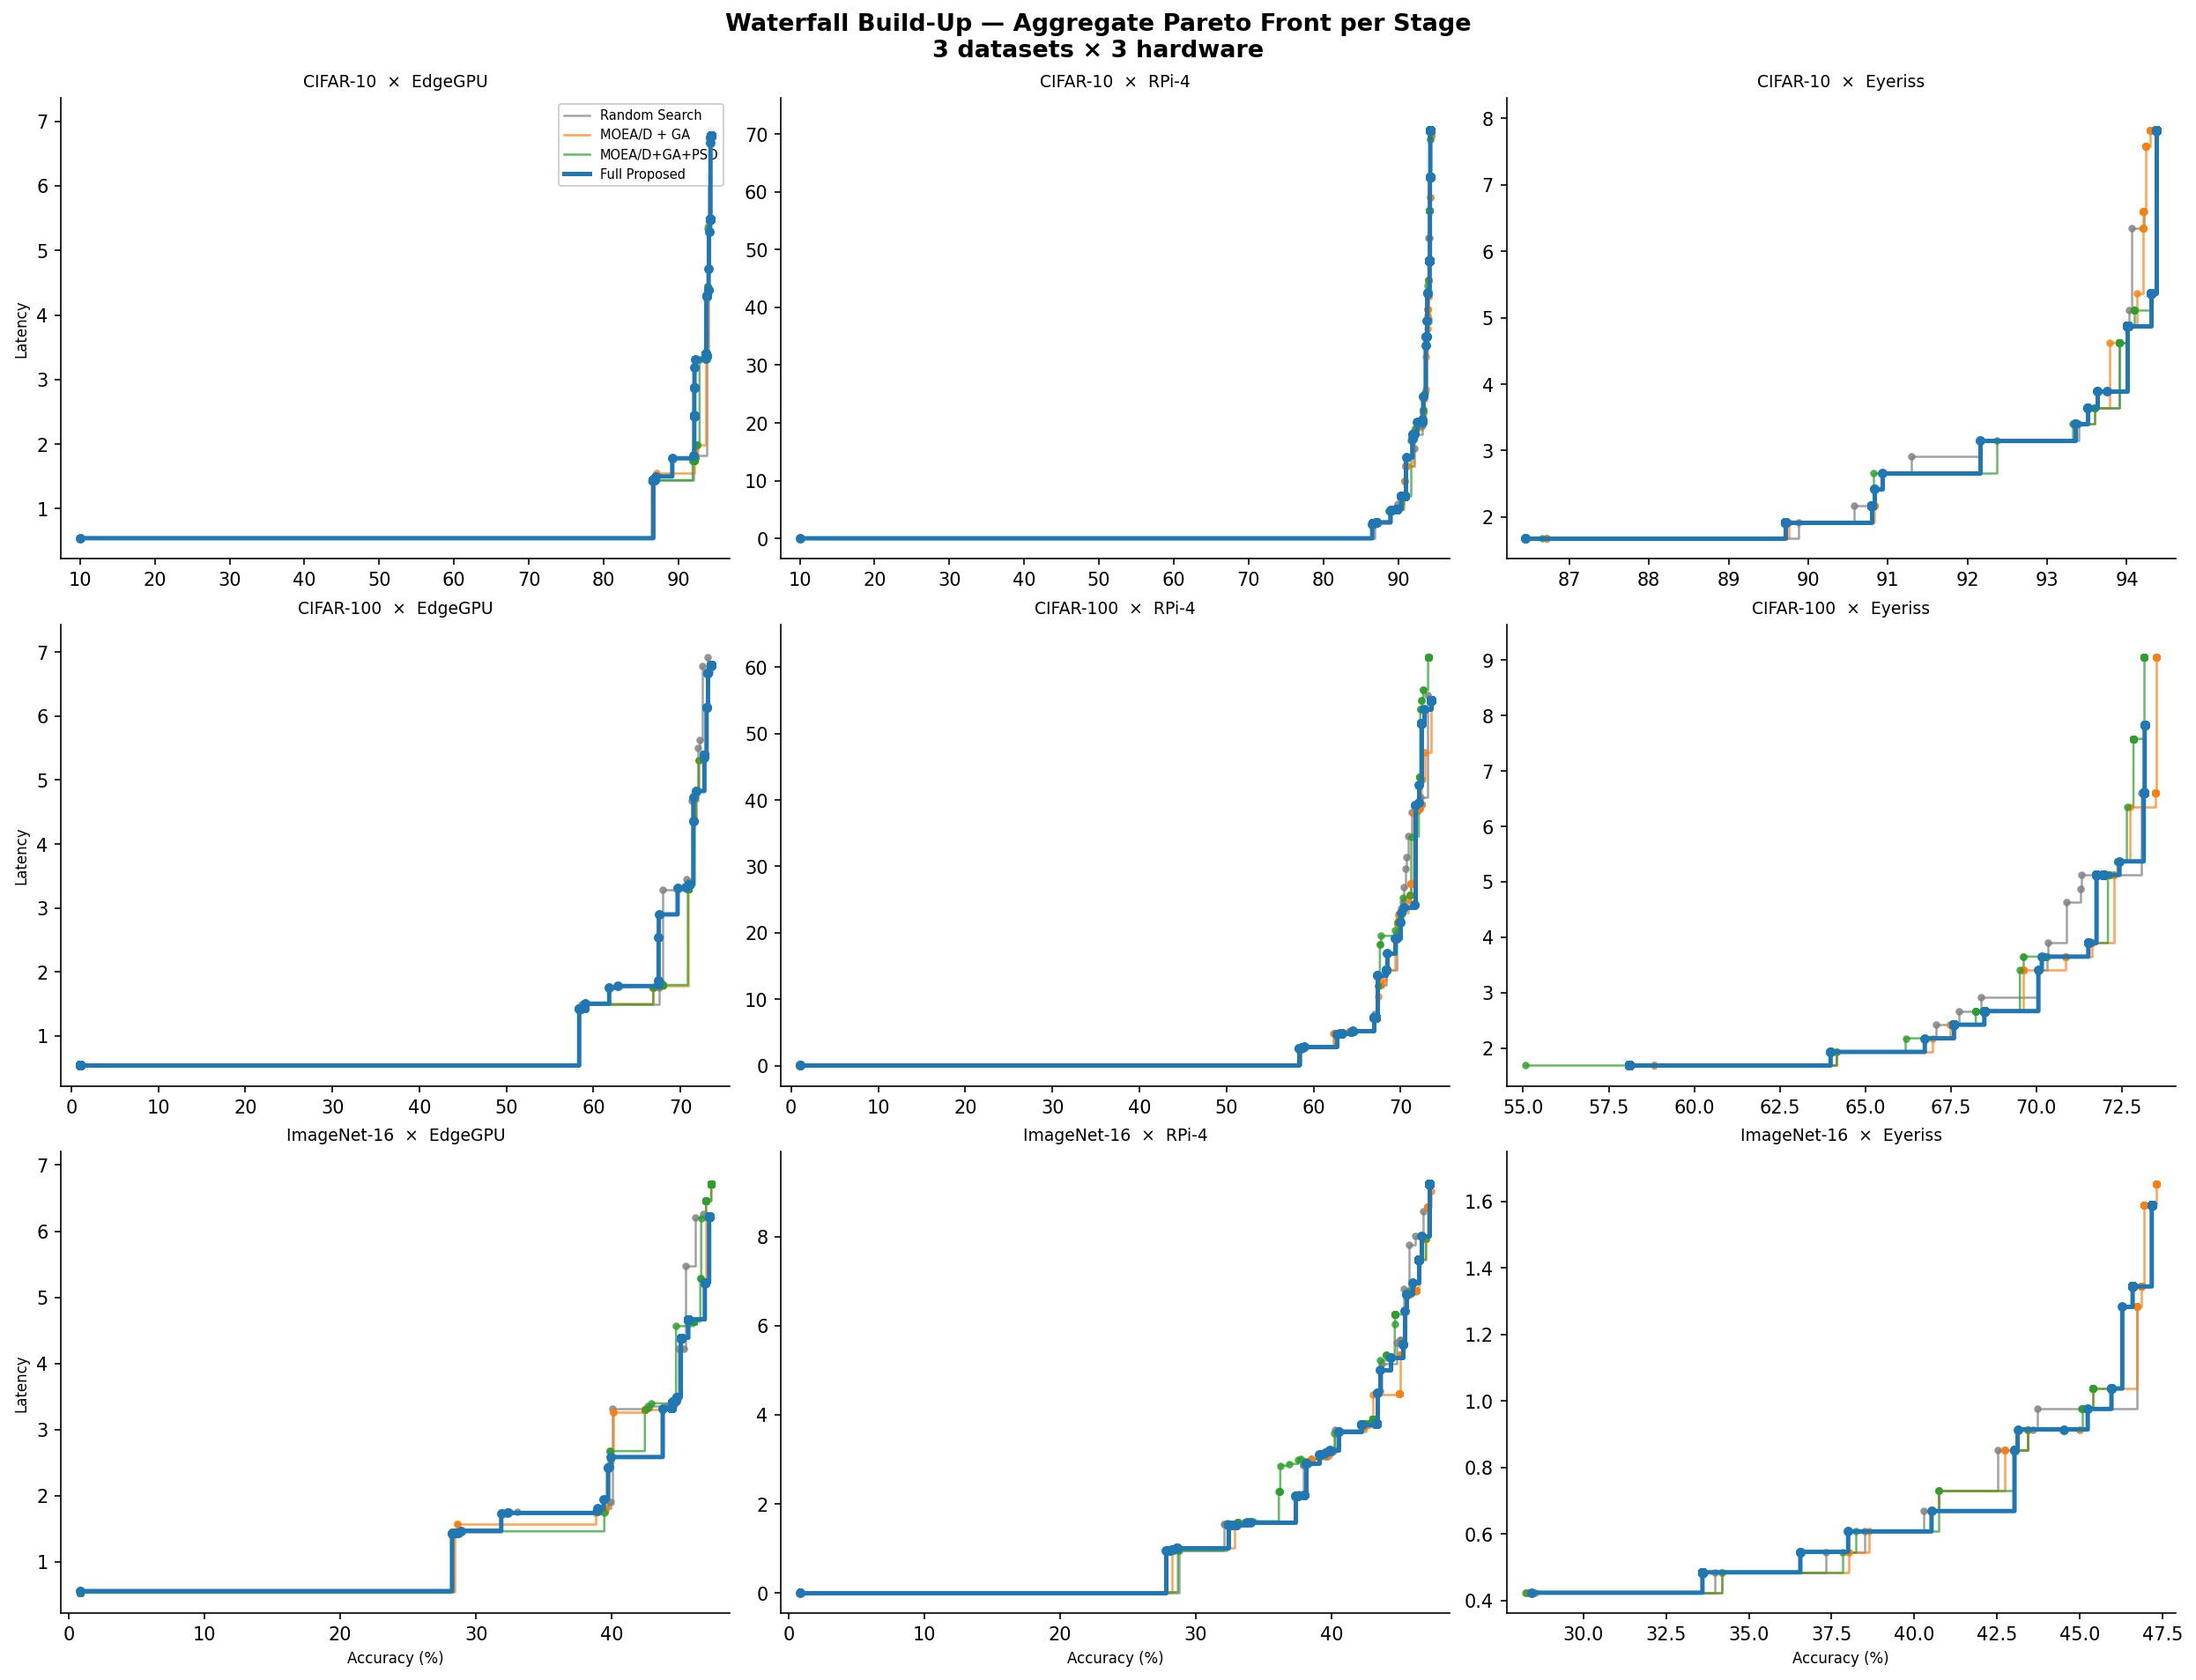

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_pareto.pdf


In [3]:
# ── Cell 3: 3×3 Pareto front overlay grid ────────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(DATASETS),
    ncols=len(HARDWARE),
    figsize=(5.5 * len(HARDWARE), 4.2 * len(DATASETS)),
    constrained_layout=True,
)
fig.suptitle(
    "Waterfall Build-Up — Aggregate Pareto Front per Stage\n"
    "3 datasets × 3 hardware",
    fontsize=13, fontweight="bold",
)

missing = []
for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax      = axes[r][c]
        entries = stage_data[ds][hw]

        if not entries:
            ax.text(0.5, 0.5, f"No data\n{DS_LABEL[ds]} / {HW_LABEL[hw]}",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="grey")
            ax.set_xticks([]); ax.set_yticks([])
            missing.append(f"{ds}/{hw}")
            continue

        all_acc = np.concatenate([e["acc"] for e in entries])
        all_lat = np.concatenate([e["lat"] for e in entries])
        xrng = max(all_acc.max() - all_acc.min(), 0.1)
        yrng = max(all_lat.max() - all_lat.min(), 1e-6)
        ax.set_xlim(all_acc.min() - xrng * 0.03, all_acc.max() + xrng * 0.03)
        ax.set_ylim(all_lat.min() - yrng * 0.05, all_lat.max() + yrng * 0.08)

        for entry in entries:
            is_full = entry["label"] == "Full Proposed"
            ax.step(entry["acc"], entry["lat"], where="post",
                    color=entry["color"],
                    linewidth=2.4 if is_full else 1.2,
                    alpha=1.0 if is_full else 0.72,
                    label=entry["label"],
                    zorder=10 if is_full else 4)
            ax.scatter(entry["acc"], entry["lat"],
                       s=18 if is_full else 10,
                       color=entry["color"],
                       alpha=1.0 if is_full else 0.72,
                       zorder=11 if is_full else 5)

        ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
        if c == 0:
            ax.set_ylabel("Latency", fontsize=8)
        if r == len(DATASETS) - 1:
            ax.set_xlabel("Accuracy (%)", fontsize=8)
        if r == 0 and c == 0:
            ax.legend(fontsize=7, loc="upper right", ncol=1, framealpha=0.88)

grid_path = FIGURES_DIR / "waterfall_3x3_pareto.pdf"
plt.savefig(grid_path, bbox_inches="tight")
plt.show()
print(f"Saved → {grid_path}")
if missing:
    print(f"Missing combos: {', '.join(missing)}")


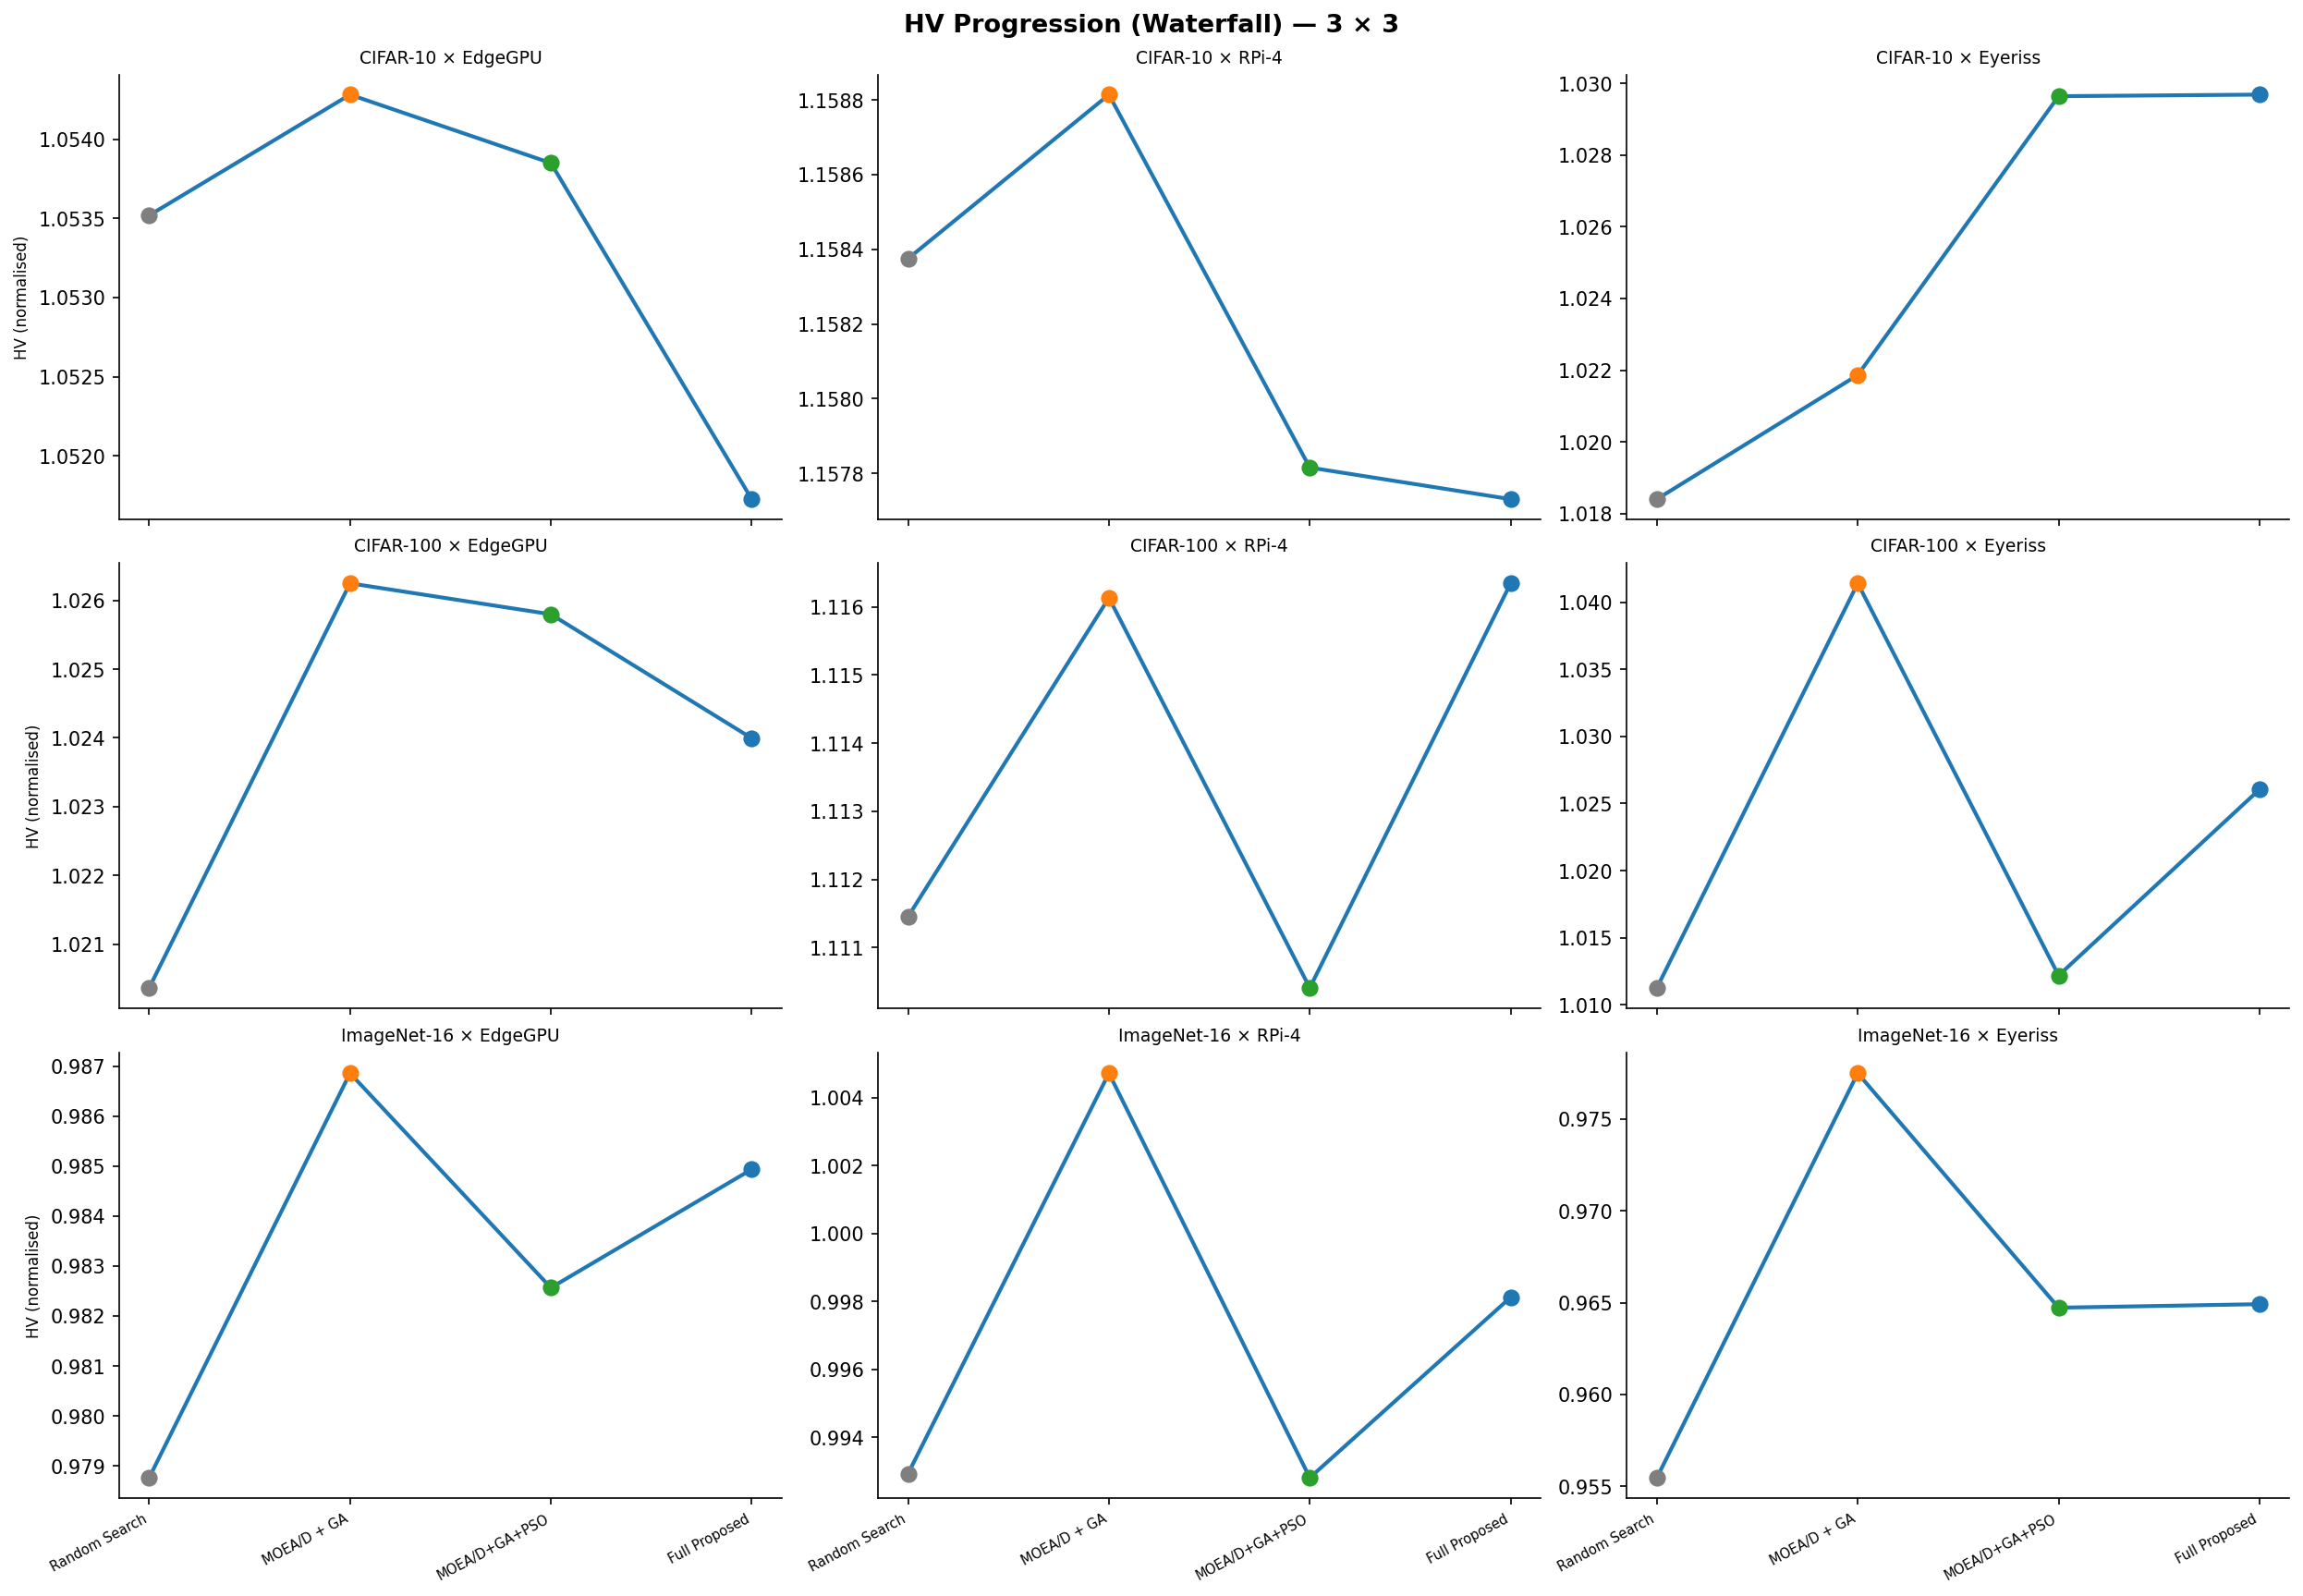

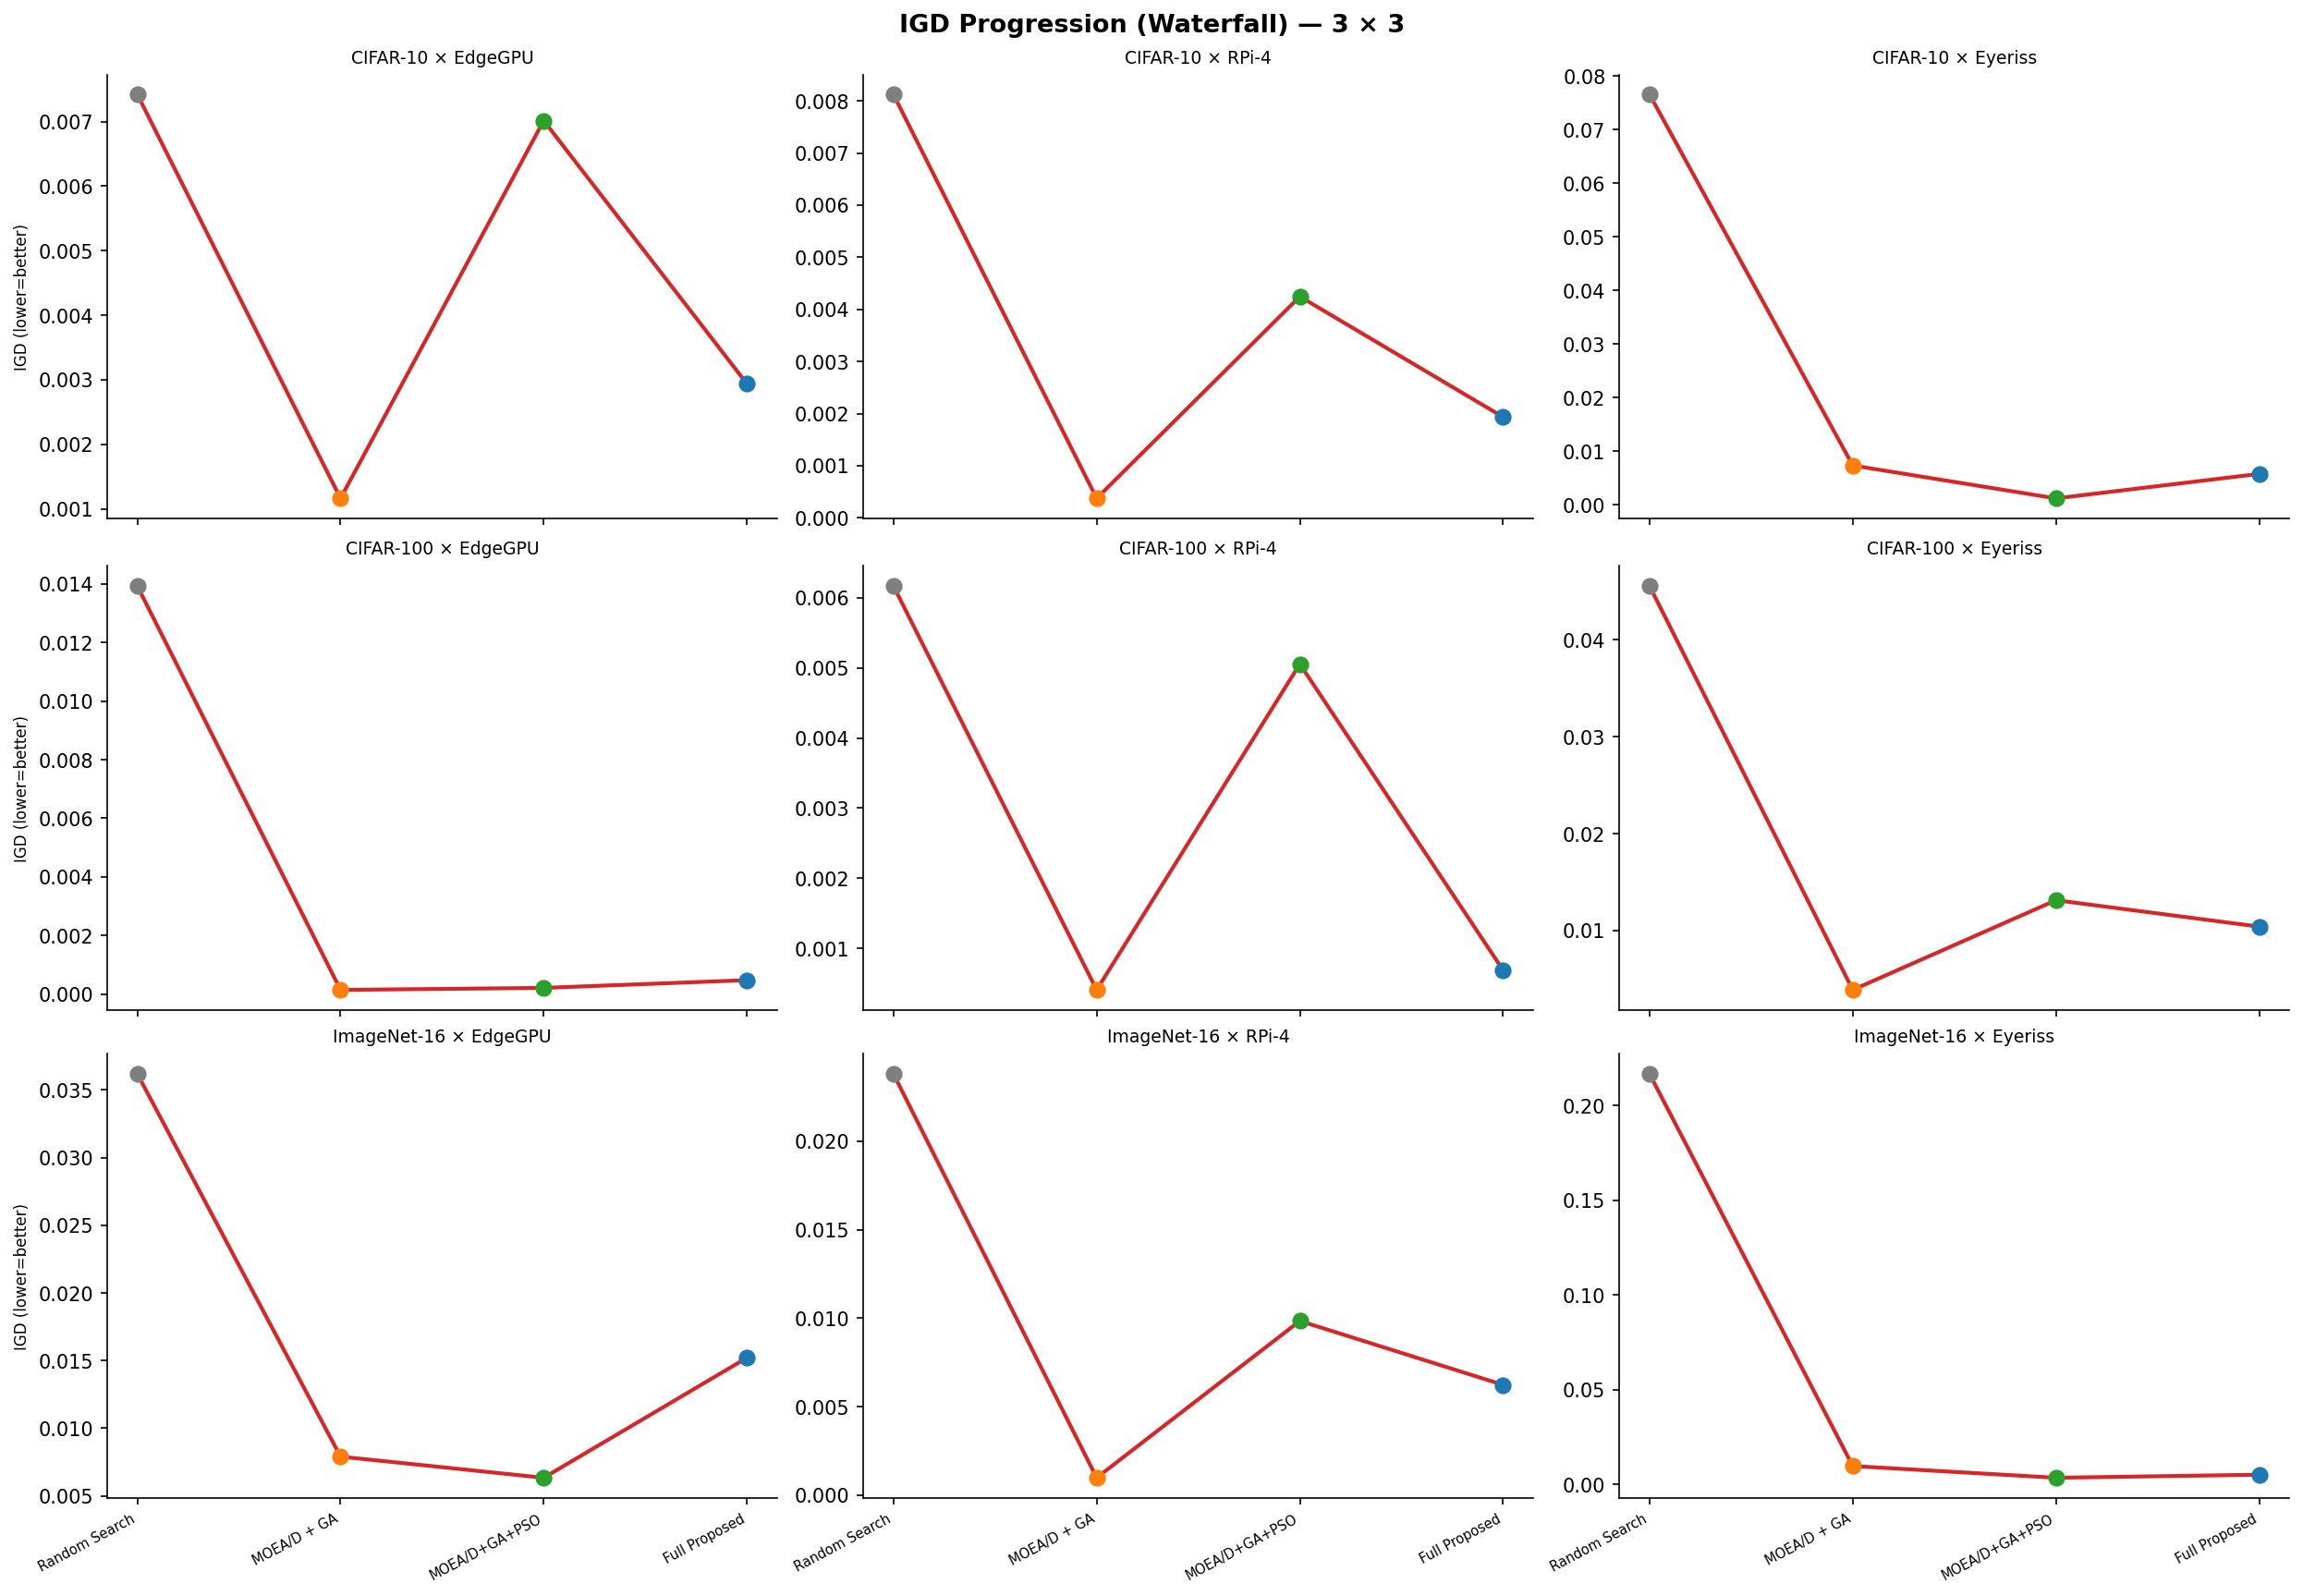

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_hv.pdf
Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_igd.pdf


In [4]:
# ── Cell 4: 3×3 HV + IGD progression line charts ─────────────────────────────
stage_labels = [s[1] for s in STAGES]

fig_hv,  axes_hv  = plt.subplots(len(DATASETS), len(HARDWARE),
                                  figsize=(5.5 * len(HARDWARE), 3.8 * len(DATASETS)),
                                  constrained_layout=True, sharex=True)
fig_igd, axes_igd = plt.subplots(len(DATASETS), len(HARDWARE),
                                  figsize=(5.5 * len(HARDWARE), 3.8 * len(DATASETS)),
                                  constrained_layout=True, sharex=True)
fig_hv.suptitle("HV Progression (Waterfall) — 3 × 3",  fontsize=13, fontweight="bold")
fig_igd.suptitle("IGD Progression (Waterfall) — 3 × 3", fontsize=13, fontweight="bold")

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax_hv  = axes_hv[r][c]
        ax_igd = axes_igd[r][c]
        subset = metrics_df[
            (metrics_df["ds_key"] == ds) & (metrics_df["hw_key"] == hw)
        ].sort_values("stage_idx")

        if subset.empty or subset["HV"].isna().all():
            for ax in (ax_hv, ax_igd):
                ax.text(0.5, 0.5, "No data", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, color="grey")
                ax.set_xticks([]); ax.set_yticks([])
            continue

        xs   = subset["stage_idx"].tolist()
        hvs  = subset["HV"].tolist()
        igds = subset["IGD"].tolist()
        cmap = [STAGES[i][2] for i in xs]

        # HV
        ax_hv.plot(xs, hvs, "-o", color="#1f77b4", linewidth=2)
        for xi, hvi, ci in zip(xs, hvs, cmap):
            ax_hv.scatter(xi, hvi, color=ci, s=60, zorder=5)
        ax_hv.set_xticks(xs)
        ax_hv.set_xticklabels([stage_labels[i] for i in xs], rotation=28, ha="right", fontsize=7)
        ax_hv.set_title(f"{DS_LABEL[ds]} × {HW_LABEL[hw]}", fontsize=9)
        if c == 0: ax_hv.set_ylabel("HV (normalised)", fontsize=8)

        # IGD
        ax_igd.plot(xs, igds, "-o", color="#d62728", linewidth=2)
        for xi, igdi, ci in zip(xs, igds, cmap):
            ax_igd.scatter(xi, igdi, color=ci, s=60, zorder=5)
        ax_igd.set_xticks(xs)
        ax_igd.set_xticklabels([stage_labels[i] for i in xs], rotation=28, ha="right", fontsize=7)
        ax_igd.set_title(f"{DS_LABEL[ds]} × {HW_LABEL[hw]}", fontsize=9)
        if c == 0: ax_igd.set_ylabel("IGD (lower=better)", fontsize=8)

fig_hv.savefig(FIGURES_DIR / "waterfall_3x3_hv.pdf",  bbox_inches="tight")
fig_igd.savefig(FIGURES_DIR / "waterfall_3x3_igd.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR}/waterfall_3x3_hv.pdf")
print(f"Saved → {FIGURES_DIR}/waterfall_3x3_igd.pdf")


In [5]:
# ── Cell 5: Summary table — ΔHV and ΔIGD from Stage-1 to Full ─────────────────
if not metrics_df.empty:
    stage1_label = STAGES[0][1]
    full_label   = STAGES[-1][1]

    s1   = metrics_df[metrics_df["Stage"] == stage1_label][["Dataset", "Hardware", "HV", "IGD"]]
    full = metrics_df[metrics_df["Stage"] == full_label][["Dataset", "Hardware", "HV", "IGD"]]

    merged = s1.merge(full, on=["Dataset", "Hardware"], suffixes=("_s1", "_full"))
    merged["ΔHV"]  = merged["HV_full"]  - merged["HV_s1"]
    merged["ΔIGD"] = merged["IGD_full"] - merged["IGD_s1"]   # negative = improvement

    display_cols = ["Dataset", "Hardware",
                    "HV_s1", "HV_full",  "ΔHV",
                    "IGD_s1", "IGD_full", "ΔIGD"]
    fmt = {k: "{:.4f}" for k in display_cols if k not in ("Dataset", "Hardware")}
    print(f"Stage-1 ({stage1_label})  vs  Full Proposed ({full_label})\n")
    print(merged[display_cols].to_string(index=False))

    merged.to_csv(FIGURES_DIR / "waterfall_summary.csv", index=False)
    print(f"\nSaved → {FIGURES_DIR}/waterfall_summary.csv")


Stage-1 (Random Search)  vs  Full Proposed (Full Proposed)

    Dataset Hardware    HV_s1  HV_full       ΔHV   IGD_s1  IGD_full      ΔIGD
   CIFAR-10  EdgeGPU 1.053520 1.051725 -0.001795 0.007417  0.002938 -0.004480
   CIFAR-10    RPi-4 1.158375 1.157731 -0.000644 0.008120  0.001935 -0.006185
   CIFAR-10  Eyeriss 1.018403 1.029686  0.011283 0.076554  0.005778 -0.070776
  CIFAR-100  EdgeGPU 1.020367 1.023995  0.003628 0.013920  0.000479 -0.013440
  CIFAR-100    RPi-4 1.111456 1.116346  0.004890 0.006164  0.000692 -0.005472
  CIFAR-100  Eyeriss 1.011270 1.026047  0.014777 0.045545  0.010401 -0.035144
ImageNet-16  EdgeGPU 0.978761 0.984936  0.006175 0.036186  0.015208 -0.020978
ImageNet-16    RPi-4 0.992929 0.998123  0.005194 0.023800  0.006236 -0.017563
ImageNet-16  Eyeriss 0.955471 0.964914  0.009443 0.216530  0.005227 -0.211303

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_summary.csv
